<a href="https://colab.research.google.com/github/Jeanbaptiste-tech-dev/projet_prediction_cr-dit_bancaire/blob/main/projet_prediction_cr%C3%A9dit_bancaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle

In [ ]:
#lire la base de données
df=pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
pd.set_option('display.max_rows',df.shape[0]+1)

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000000,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.000000,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000000,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.000000,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000000,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.000000,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.000000,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.000000,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.000000,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.000000,349.0,360.0,1.0,Semiurban,N


In [ ]:
pd.set_option('display.max_rows',10)

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
#valeurs manquantes
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
...,...
Loan_ID,0
CoapplicantIncome,0
ApplicantIncome,0
Property_Area,0


In [ ]:
df.describe(include='O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
#traitement des valeurs manquantes
cat_data=[]
num_data=[]
for i,c in enumerate(df.dtypes):
  if c==object:
    cat_data.append(df.iloc[:,i])
  else:
    num_data.append(df.iloc[:,i])
cat_data=pd.DataFrame(cat_data).transpose()
num_data=pd.DataFrame(num_data).transpose()

In [ ]:
#Pour les ariables catégoriques, on va remplacer les valeurs manquantes par les valeurs qui se repetent
cat_data=cat_data.fillna(cat_data.mode().iloc[0])
cat_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Property_Area,0
Loan_Status,0


In [ ]:
#Pour les valeurs numériques, on va remplacer les valeurs manquantes par la valeur précedente
num_data=num_data.bfill()
num_data.isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [ ]:
num_data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849.0,0.0,128.0,360.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0
2,3000.0,0.0,66.0,360.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0
4,6000.0,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900.0,0.0,71.0,360.0,1.0
610,4106.0,0.0,40.0,180.0,1.0
611,8072.0,240.0,253.0,360.0,1.0
612,7583.0,0.0,187.0,360.0,1.0


In [ ]:
#transformer la colonne target
target_value={"Y":1,"N":0}
target=cat_data['Loan_Status']
cat_data.drop('Loan_Status',axis=1,inplace=True)
target=target.map(target_value)
target

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [ ]:
#Remplacer  les valeiurs catégoriques par des valeurs numérique 0,1,2...
le=LabelEncoder()
for i in cat_data.columns:
  cat_data[i]=le.fit_transform(cat_data[i])
cat_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,0,1,0,0,0,0,2
1,1,1,1,1,0,0,0
2,2,1,1,0,0,1,2
3,3,1,1,0,1,0,2
4,4,1,0,0,0,0,2
...,...,...,...,...,...,...,...
609,609,0,0,0,0,0,0
610,610,1,1,3,0,0,0
611,611,1,1,1,0,0,2
612,612,1,1,2,0,0,2


In [ ]:
cat_data.drop("Loan_ID",axis=1,inplace=True)

In [ ]:
# Concatener cat_Data et num_Data et spécifier la colonne target
X=pd.concat([cat_data,num_data], axis=1)
y=target
y

,Loan_Status
0,1
1,0
2,1
3,1
4,1
...,...
609,1
610,1
611,1
612,1


In [ ]:
target.value_counts()
#print(target.head(10))

,count
Loan_Status,
1,422
0,192


oui : 0.3127035830618892
non : 0.6872964169381107


Text(0, 0.5, 'Nombre de dossiers')

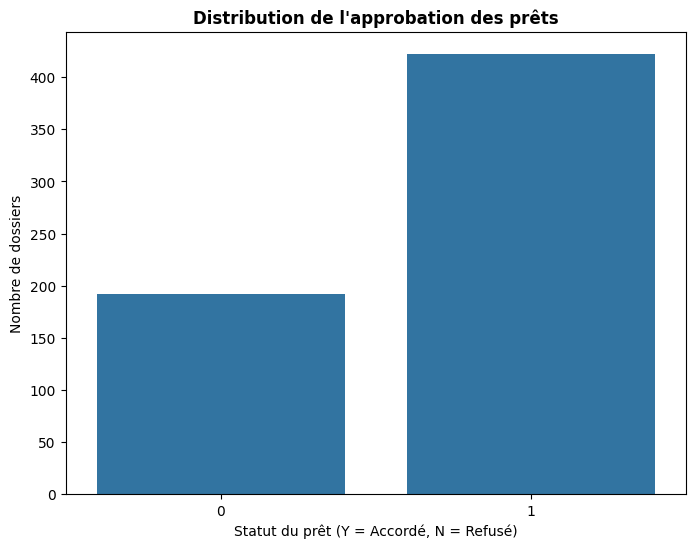

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x=target)
yes=target.value_counts()[0]/len(target)
no=target.value_counts()[1]/len(target)

print("oui :",yes)
print("non :",no)
plt.title("Distribution de l'approbation des prêts", fontsize=12, fontweight='bold')
plt.xlabel("Statut du prêt (Y = Accordé, N = Refusé)", fontsize=10)
plt.ylabel("Nombre de dossiers", fontsize=10)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


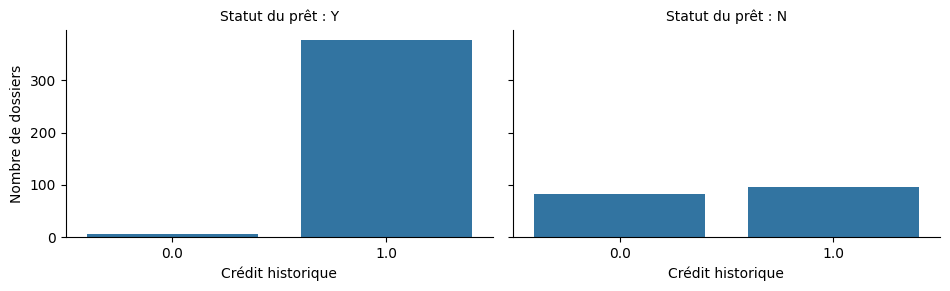

In [ ]:
grid=sns.FacetGrid(df,col='Loan_Status',aspect=1.6)
grid.map(sns.countplot,'Credit_History')
grid.set_titles("Statut du prêt : {col_name}")
grid.set_axis_labels("Crédit historique", "Nombre de dossiers")

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


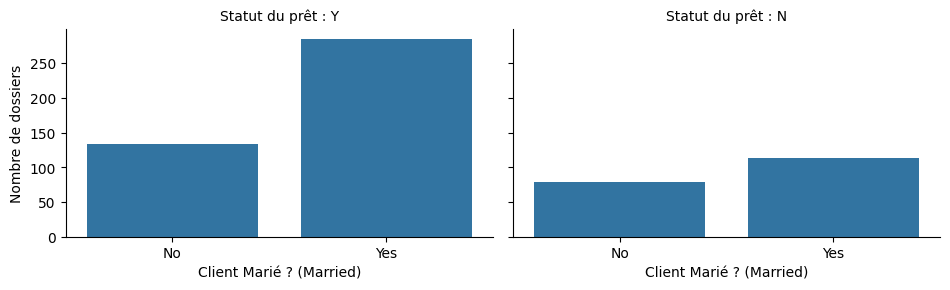

In [ ]:
grid=sns.FacetGrid(df,col='Loan_Status',aspect=1.6)
grid.map(sns.countplot,'Married')
grid.set_titles("Statut du prêt : {col_name}")
grid.set_axis_labels("Client Marié ? (Married)", "Nombre de dossiers")

In [ ]:
# Diviser la base de donnée en base de donnée test et base de donnée entrainement
sss=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train,test in sss.split(X,y):
  X_train,X_test=X.iloc[train],X.iloc[test]
  y_train,y_test=y.iloc[train],y.iloc[test]
print('X_train taille:', X_train.shape)
print('X_test taille:', X_test.shape)
print('y_train taille:', y_train.shape)
print('y_test taille:', y_test.shape)

X_train taille: (491, 11)
X_test taille: (123, 11)
y_train taille: (491,)
y_test taille: (123,)


In [ ]:
#On va appliquer trois algorithmes Logistic Regression, KNN, DecisionTree
models={
    'Logistic Regression':LogisticRegression(random_state=42,max_iter=1000),
    'KNN':KNeighborsClassifier(),
    'Decision Tree':DecisionTreeClassifier(max_depth=1,random_state=42)
}
# La fonction de précision
def accu(y_true,y_pred,retu=False):
  acc=accuracy_score(y_true,y_pred)
  if retu:
    return acc
  else:
    print(f'La précision du modèle est:', {acc})

#C'est la fonction d'application des modèles
def train_test_eval(models,X_train,X_test,y_train,y_test):
  for name,model in models.items():
    print(name,':')
    model.fit(X_train,y_train)
    score = accu(y_test, model.predict(X_test), retu=True)
    print(f"Précision : {score}")

    print('-'*30)

train_test_eval(models,X_train,X_test,y_train,y_test)

Logistic Regression :
Précision : 0.8536585365853658
------------------------------
KNN :
Précision : 0.6504065040650406
------------------------------
Decision Tree :
Précision : 0.8455284552845529
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Appliquer la regression logistique sur notre base de donnée
Classifier=LogisticRegression()
Classifier.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
train_test_eval(models,X_train,X_test,y_train,y_test)

Logistic Regression :
Précision : 0.8536585365853658
------------------------------
KNN :
Précision : 0.6504065040650406
------------------------------
Decision Tree :
Précision : 0.8455284552845529
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


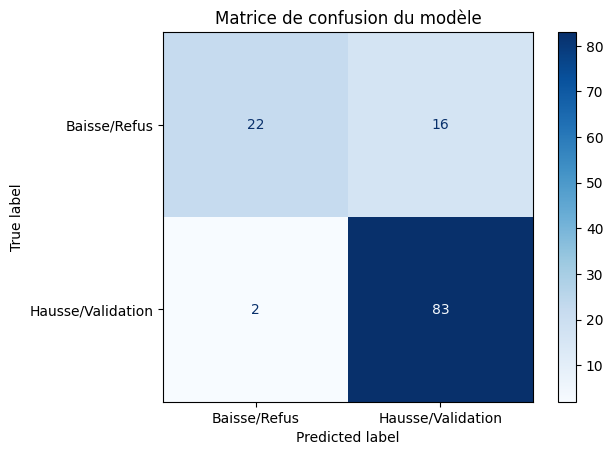

In [ ]:
# 1. Calculer la matrice de confusion
# Remplace 'Classifier' par le nom du modèle entraîné sur X_train
y_pred = Classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 2. L'afficher de manière stylisée
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baisse/Refus', 'Hausse/Validation'])
disp.plot(cmap=plt.cm.Blues)

# 3. Sauvegarder l'image pour ton rapport LaTeX
plt.title("Matrice de confusion du modèle")
plt.savefig("matrice_confusion.png", dpi=300, bbox_inches='tight')
plt.show()

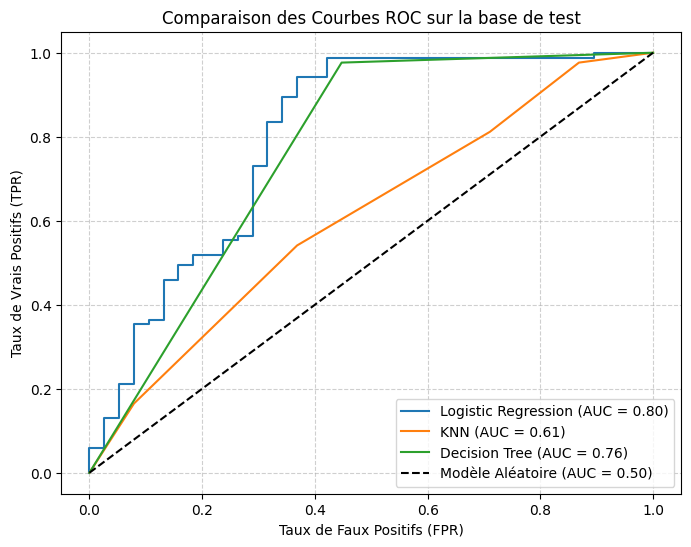

In [ ]:
plt.figure(figsize=(8, 6))

# Boucle sur tes modèles pour calculer et tracer la courbe ROC de chacun
for name, model in models.items():
    # Attention : la courbe ROC utilise les probabilités de la classe positive (1)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Cas exceptionnels si un modèle n'a pas predict_proba
        y_proba = model.decision_function(X_test)

    # Calcul des taux de Faux Positifs (fpr) et Vrais Positifs (tpr)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # Calcul du score AUC
    auc_score = roc_auc_score(y_test, y_proba)

    # Ajout de la courbe au graphique
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

# Tracé de la diagonale de référence (modèle aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Modèle Aléatoire (AUC = 0.50)')

# Personnalisation esthétique du graphique
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Comparaison des Courbes ROC sur la base de test")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# Sauvegarde de l'image de haute qualité pour LaTeX
plt.savefig("courbe_roc_comparative.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Enregostrer me modèle
pickle.dump(Classifier,open('model.pkl','wb'))